Задание 1.
Реализуйте базовый класс Account, который моделирует поведение
банковского счёта. Этот класс должен не только выполнять базовые
операции, но и вести детальный учёт всех действий, а также предоставлять
аналитику по истории операций.
Этап 1. Реализация базового класса Account
Класс должен быть инициализирован с параметрами:
 account_holder (str) — имя владельца счёта;
 balance (float, по умолчанию 0) — начальный баланс счёта, не может
быть отрицательным.
Атрибуты:
 _account_counter — приватный атрибут для хранения количества
созданных счетов. Отсчет начинается с 1000;
 holder — хранит имя владельца;
 account_number — хранит номер счёта;
 _balance — приватный атрибут для хранения текущего баланса;
 operations_history — список или другая структура для хранения
истории операций.
Важно: каждая операция должна храниться не просто как число, а как
структурированная информация, например, словарь, кортеж или класс.
Минимальный набор данных для операции: тип операции ('deposit' или
'withdraw'), сумма, дата и время операции, текущий баланс после операции,
статус ('success' или 'fail').
Этап 2. Реализация методов
1. __init__(self, account_holder, balance=0) — конструктор. Обратите
внимание, что в конструкторе должен автоматически формироваться
номер счёта в формате ‘ACC-XXXX’, где XXXX — порядковый номер
счёта;
2. deposit(self, amount) — метод для пополнения счёта:
 принимает сумму (должна быть положительной), попытка
положить отрицательную сумму, должна вызывать исключение;
 в случае успеха обновляет баланс и добавляет запись в историю
операций.
3. withdraw(self, amount) — метод для снятия средств:
 принимает сумму (должна быть положительной);
 проверяет, достаточно ли средств на счёте, если нет — операция
не проходит, но ее попытка с статусом 'fail' все равно фиксируется
в истории;
 в случае успеха обновляет баланс и добавляет запись в историю.
4. get_balance(self) — метод, который возвращает текущий баланс.
5. get_history(self) — метод, который возвращает историю операций.
Важно: продумайте, в каком формате его вернуть. Для работы с датой и
временем используйте модуль datetime. Получить текущее время можно с
помощью datetime.now().


In [1]:
from datetime import datetime as dt
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import re

In [2]:
class Account:
    # приватный атрибут для хранения количества созданных счетов. Отсчет начинается с 1000;
    _account_counter = 1000

    def __init__(self, account_holder: str, balance: float = 0.0) -> None:
        try:
            if balance < 0:
                raise ValueError('начальный баланс счёта не может быть отрицательным.')
            self.holder = account_holder  # хранит имя владельца;
            self.operations_history = []  # список для хранения истории операций.
            self._balance = balance  # приватный атрибут для хранения текущего баланса;
            # приватно хранит номер счёта в нужном формате (ACC-XXXX); !!!!
            self._account_number = f'ACC-{Account._account_counter}'

            Account._account_counter += (
                1  # прибавляем к счетчику аккаунтов новый аккаунт
            )
        except ValueError as e:
            print(f'Ошибка при создании счета {e}')

    def __str__(self) -> str:
        return f'Аккаунт номер: {self._account_number}. Баланс: {self.get_balance}'

    # оборачиваем приватный атрибут
    @property
    def get_balance(self) -> float:
        '''Геттер. Возращает текущий баланс счёта для чтения'''
        return self._balance

    @get_balance.setter
    def get_balance(self, amount):
        '''Сеттер для защиты от отрицательного баланса счёта'''
        try:
            if amount < 0:
                raise ValueError('баланс счёта не может быть отрицательным.')
            self._balance = amount
        except ValueError as e:
            print(f'{e}')

    def deposit(self, amount: float) -> float:
        '''Функция для пополнения счёта'''
        try:
            if amount <= 0:
                raise ValueError('Неудачно. Сумма пополнения должна быть > 0.')

            self.get_balance += amount

            self._new_operation('deposit', amount, 'success')
            return self.get_balance
        except ValueError as e:
            self._new_operation('deposit', amount, 'fail')
            print(f'{e}')

    def withdraw(self, amount: float) -> float:
        '''Функция для снятия денег со счёта'''
        try:
            if amount <= 0:
                raise ValueError('Неудачно. Сумма снятия должна быть > 0.')

            if amount > self.get_balance:
                raise ValueError('Неудачно. Недостаточно средств.')

            self.get_balance -= amount

            self._new_operation('withdraw', amount, 'success')
        except ValueError as e:
            self._new_operation('withdraw', amount, 'fail')
            print(f'{e}')
        return self.get_balance

    def _new_operation(self, type: str, amount: float, status: str):
        '''Функция для добавления операции в историю операций'''
        try:
            self.operations_history.append(
                {
                    'type': type,
                    'amount': amount,
                    'dt': dt.now().strftime('%H:%M:%S, %d/%m/%Y'),
                    'new_balance': self.get_balance,
                    'status': status,
                }
            )
        except ValueError as e:
            print(f'{e}')

    def get_history(self) -> list:
        '''Возращает историю операций'''
        return self.operations_history

    def plot_history(self):
        '''Создаем визуализацию изменения баланса с помощью Pandas и plot'''
        if not self.operations_history:
            print('Операций не было')
            return

        def choose_color_of_row(row):
            if row['status'] == 'fail':
                return 'red'
            elif row['type'] == 'deposit':
                return 'green'
            else:
                return 'blue'

        table_of_operations = pd.DataFrame(self.operations_history)

        table_of_operations['color'] = table_of_operations.apply(
            choose_color_of_row, axis=1
        )

        table_of_operations['dt'] = pd.to_datetime(table_of_operations['dt'])

        plt.figure(figsize=(10, 5))
        plt.plot(
            table_of_operations['dt'],
            table_of_operations['new_balance'],
            color='lightgray',
            linestyle='-',
            zorder=1,
        )
        plt.scatter(
            table_of_operations['dt'],
            table_of_operations['new_balance'],
            c=table_of_operations['color'],
            s=80,  # размер точек
            edgecolors='black',
            linewidths=0.8,
            zorder=2,
        )
        plt.title(
            f'График изменения баланса аккаунта {self._account_number}, владельца {self.holder}'
        )
        plt.xlabel('Дата операции')
        plt.ylabel('Баланс после операции')
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.tight_layout()
        plt.show()

    def __repr__(self):
        return f'Account{self._account_number}, holder {self.holder}, operations_history {self.operations_history}, balance {self.get_balance}'

In [3]:
acc = Account('Alex', 54)
acc.get_balance
acc.deposit(50)
acc.withdraw(100)
acc.deposit(510)
acc.deposit(50)
acc.withdraw(1040)
acc.withdraw(1010)
acc.withdraw(100)
acc.deposit(50)
acc.deposit(50)
acc.deposit(510)

acc.get_history()

Неудачно. Недостаточно средств.
Неудачно. Недостаточно средств.


[{'type': 'deposit',
  'amount': 50,
  'dt': '23:20:34, 08/11/2025',
  'new_balance': 104,
  'status': 'success'},
 {'type': 'withdraw',
  'amount': 100,
  'dt': '23:20:34, 08/11/2025',
  'new_balance': 4,
  'status': 'success'},
 {'type': 'deposit',
  'amount': 510,
  'dt': '23:20:34, 08/11/2025',
  'new_balance': 514,
  'status': 'success'},
 {'type': 'deposit',
  'amount': 50,
  'dt': '23:20:34, 08/11/2025',
  'new_balance': 564,
  'status': 'success'},
 {'type': 'withdraw',
  'amount': 1040,
  'dt': '23:20:34, 08/11/2025',
  'new_balance': 564,
  'status': 'fail'},
 {'type': 'withdraw',
  'amount': 1010,
  'dt': '23:20:34, 08/11/2025',
  'new_balance': 564,
  'status': 'fail'},
 {'type': 'withdraw',
  'amount': 100,
  'dt': '23:20:34, 08/11/2025',
  'new_balance': 464,
  'status': 'success'},
 {'type': 'deposit',
  'amount': 50,
  'dt': '23:20:34, 08/11/2025',
  'new_balance': 514,
  'status': 'success'},
 {'type': 'deposit',
  'amount': 50,
  'dt': '23:20:34, 08/11/2025',
  'new_b

Этап 3. Визуализация истории операций. Дополнительное задание для
претендующих на оценку 8 и выше баллов (выполняется по желанию).
1. Создайте метод plot_history(self), который использует библиотеку
Pandas для создания датафрейма из истории операций.
2. Продумайте, с помощью какой библиотеки можно отобразить
изменение баланса с течением времени. Постройте простой
линейный график, где по оси X будет время операции, а по оси Y —
баланс после каждой операции. График должен иметь заголовок,
подписи осей.


In [4]:
# Иммитируем добавление операций в разное время(например каждый месяц)
start_date = dt(2025, 1, 1)

# Проходим по всем операциям и сдвигаем даты на месяц вперёд
for i, op in enumerate(acc.operations_history):
    month = start_date.month + i
    year = 2025
    new_dt = dt(year, month, 1)
    op["dt"] = new_dt.strftime("%d/%m/%Y")
    i += 1

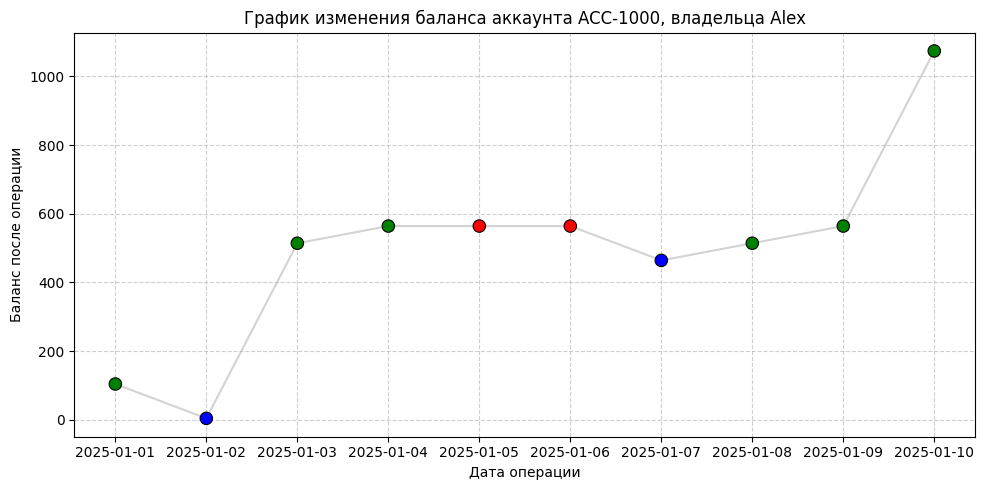

In [5]:
acc.plot_history()  # операции пополнения - зеленые, снятия - синие, неудачные - красные

Задание 2.
Этап 4. Реализация наследования
1. Реализуйте два класса CheckingAccount (расчётный счёт) и
SavingsAccount (сберегательный счёт), которые отражают абстракцию
базового поведения банковских аккаунтов:
 наследуются от базового класса Account;
 хранят атрибут класса account_type.
2. Класс SavingsAccount (сберегательный счёт) дополнительно должен
реализовывать метод расчёта процентов на остаток
apply_interest(self, rate) (например, 7% на остаток).
3. Класс SavingsAccount (сберегательный счёт) позволяет снимать
деньги только до определенного порога баланса: нельзя снять
больше 50% от баланса. Переопределите метод снятия со счёта.
4. Реализуйте валидацию на отрицательные суммы и корректность
имени владельца:
 имя владельца счёта должно быть в формате «Имя Фамилия» с
заглавных букв, кириллицей или латиницей, иначе — должно
вызываться исключение;
 попытка положить отрицательную сумму должна вызывать
исключение.
5. Реализуйте метод для анализа истории транзакций по размеру и дате:
 метод должен выводить последние n крупных операций.


In [6]:
# добавляем новые валидации и дополнения из задания 2 в уже созданный класс Account


class Account:
    # приватный атрибут для хранения количества созданных счетов. Отсчет начинается с 1000;
    _account_counter = 1000

    def __init__(self, account_holder: str, balance: float = 0.0) -> None:
        try:
            if balance < 0:
                raise ValueError('начальный баланс счёта не может быть отрицательным.')
            if not self._valid_holder(account_holder):
                raise ValueError('Имя не соотвествует формату : "Имя Фамилия"')
            self.holder = account_holder  # хранит имя владельца;
            self.operations_history = []  # список для хранения истории операций.
            self._balance = balance  # приватный атрибут для хранения текущего баланса;
            # приватно хранит номер счёта в нужном формате (ACC-XXXX); !!!!
            self._account_number = f'ACC-{Account._account_counter}'

            Account._account_counter += (
                1  # прибавляем к счетчику аккаунтов новый аккаунт
            )
        except ValueError as e:
            print(f'Ошибка при создании счета {e}')

    def __str__(self) -> str:
        return f'Аккаунт номер: {self._account_number}. Баланс: {self.get_balance}'

    # оборачиваем приватный атрибут
    @property
    def get_balance(self) -> float:
        '''Геттер. Возращает текущий баланс счёта для чтения'''
        return self._balance

    @get_balance.setter
    def get_balance(self, amount):
        '''Сеттер для защиты от отрицательного баланса счёта'''
        try:
            if amount < 0:
                raise ValueError('баланс счёта не может быть отрицательным.')
            self._balance = amount
        except ValueError as e:
            print(f'{e}')

    def deposit(self, amount: float) -> float:
        '''Функция для пополнения счёта'''
        try:
            if amount <= 0:
                raise ValueError('Неудачно. Сумма пополнения должна быть > 0.')

            self.get_balance += amount

            self._new_operation('deposit', amount, 'success')
            return self.get_balance
        except ValueError as e:
            self._new_operation('deposit', amount, 'fail')
            print(f'{e}')

    def withdraw(self, amount: float) -> float:
        '''Функция для снятия денег со счёта'''
        try:
            if amount <= 0:
                raise ValueError('Неудачно. Сумма снятия должна быть > 0.')

            if amount > self.get_balance:
                raise ValueError('Неудачно. Недостаточно средств.')

            self.get_balance -= amount

            self._new_operation('withdraw', amount, 'success')
        except ValueError as e:
            self._new_operation('withdraw', amount, 'fail')
            print(f'{e}')

    def _new_operation(self, type: str, amount: float, status: str):
        '''Функция для добавления операции в историю операций'''
        try:
            self.operations_history.append(
                {
                    'type': type,
                    'amount': amount,
                    'dt': dt.now().strftime('%H:%M:%S, %d/%m/%Y'),
                    'new_balance': self.get_balance,
                    'status': status,
                }
            )
        except ValueError as e:
            print(f'{e}')

    def get_history(self) -> list:
        '''Возращает историю операций'''
        return self.operations_history

    def show_top_operations(self, n: int = 7):
        '''Возвращает топ n(7) последних операций'''
        if not self.operations_history:
            print('Операций не было')
            return []
        top_table = pd.DataFrame(self.operations_history)
        res_table = top_table.sort_values(
            by=['amount', 'dt'], ascending=[False, False]
        ).head(n)
        print(f'Топ {n} операций:')
        print(res_table.to_string(index=False))
        return

    def plot_history(self):
        '''Создаем визуализацию изменения баланса с помощью Pandas и plot'''
        if not self.operations_history:
            print('Операций не было')
            return

        def choose_color_of_row(row):
            if row['status'] == 'fail':
                return 'red'
            elif row['type'] == 'deposit':
                return 'green'
            else:
                return 'blue'

        table_of_operations = pd.DataFrame(self.operations_history)

        table_of_operations['color'] = table_of_operations.apply(
            choose_color_of_row, axis=1
        )

        table_of_operations['dt'] = pd.to_datetime(table_of_operations['dt'])

        plt.figure(figsize=(10, 5))
        plt.plot(
            table_of_operations['dt'],
            table_of_operations['new_balance'],
            color='lightgray',
            linestyle='-',
            zorder=1,
        )
        plt.scatter(
            table_of_operations['dt'],
            table_of_operations['new_balance'],
            c=table_of_operations['color'],
            s=80,  # размер точек
            edgecolors='black',
            linewidths=0.8,
            zorder=2,
        )
        plt.title(
            f'График изменения баланса аккаунта {self._account_number}, владельца {self.holder}'
        )
        plt.xlabel('Дата операции')
        plt.ylabel('Баланс после операции')
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.tight_layout()
        plt.show()

    def __repr__(self):
        return f'Account{self._account_number}, holder {self.holder}, operations_history {self.operations_history}, balance {self.get_balance}'

    @staticmethod
    def _valid_holder(name: str) -> bool:
        '''Статическая функция проверки формата ФИ: заглавные буквы + кириллица\латинница'''
        pattrn = r"^[A-ZА-Я][a-zа-я]+ [A-ZА-Я][a-zа-я]+$"
        return bool(re.match(pattrn, name))

In [7]:
acc = Account('Polina Ivanova', 500)
acc.deposit(50)
acc.withdraw(100)
acc.deposit(510)
acc.deposit(50)
acc.withdraw(10100)
acc.deposit(50)
acc.deposit(5000)
acc.deposit(50)
acc.get_history()
acc.show_top_operations()

Неудачно. Недостаточно средств.
Топ 7 операций:
    type  amount                   dt  new_balance  status
withdraw   10100 23:20:34, 08/11/2025         1010    fail
 deposit    5000 23:20:34, 08/11/2025         6060 success
 deposit     510 23:20:34, 08/11/2025          960 success
withdraw     100 23:20:34, 08/11/2025          450 success
 deposit      50 23:20:34, 08/11/2025          550 success
 deposit      50 23:20:34, 08/11/2025         1010 success
 deposit      50 23:20:34, 08/11/2025         1060 success


In [8]:
# реализуем CheckingAccount и SavingsAccount


class CheckingAccount(Account):
    account_type = 'CheckingAccount'

In [9]:
class SavingsAccount(Account):
    account_type = 'SavingsAccount'

    def withdraw(self, amount):
        '''запрет на снятие более 50%'''
        if amount > self.get_balance * 0.5:
            self._new_operation('withdraw', amount, 'fail')
            raise ValueError(
                'На счёте этого типа нельзя снимать более 50% от баланса.')
        return super().withdraw(amount)

    def apply_interest(self, rate=0.07):
        '''Умножаем капитал на 7 процентов'''
        self.get_balance = self.get_balance + (self.get_balance * rate)
        return self.get_balance


acc = SavingsAccount('Alex Palex', 100)
print(acc.apply_interest())
# Проверим работает ли ограничение
acc.withdraw(60)

107.0


ValueError: На счёте этого типа нельзя снимать более 50% от баланса.